# Histograms

DS 2023 | Communicating with Data

## Overview

A histogram is a special case of a bar plot designed for visualizing the statistical properties of a feature. 

It has the following properties:

- On the x axis, a numerical feature is converted into a category (in effect) by binning.
- The numeric bins are represented sequentially.
- On the y axis is displayed the frequency of the observations for each bin.
- The bars are usually depicted contiguously, i.e. they touch when next to each other. Bar charts typically show separation between bars.

## Use cases

Histograms provide a quick way to inspect the centrality and dispersion of a distribution.

They allow you to inspect the shape of a distribution for modality, skew, and kurtosis.

They can also surface outliers and mutliple populations.

## Creating a histogram from scratch

Consider the following data set of yearly life expectancy rates and healthcare costs for a set of countries.

The two numeric features are good candidates for a histogram since they are ratio measures.

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [172]:
healthexp = sns.load_dataset('healthexp')
healthexp.sample(10)

,Year,Country,Spending_USD,Life_Expectancy
219,2011,USA,8079.467,78.7
191,2007,Germany,3750.787,80.1
16,1974,Germany,452.744,71.5
233,2014,Germany,5151.709,81.2
184,2006,Canada,3486.621,80.4
220,2012,Canada,4336.249,81.6
82,1988,Japan,969.251,78.4
157,2001,Great Britain,2067.167,78.2
169,2003,Great Britain,2469.159,78.4
186,2006,France,3444.855,81.0


Let's focus on life expectancy, expressed as age, where we'd expect a gaussian distribution.

If we convert the continous numbers for age to discrete integers, we can treat age as a category to group on.

Getting value counts by age produces the following bar chart.

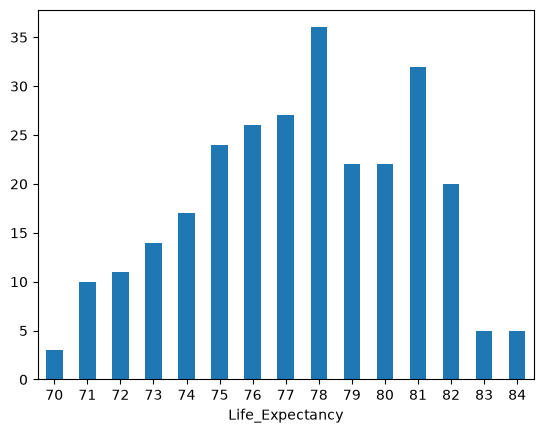

In [181]:
healthexp.Life_Expectancy.astype(int).value_counts().sort_index().plot.bar(rot=0)
plt.show()

Note that we have to sort the index since `.value_counts()` sorts by count. 

We need the age categories to be in sequential order.

Now, to meet the design requirements of a histogram, we can adjust the width of the bars to make them touch.

We do this by setting `width = 1`.

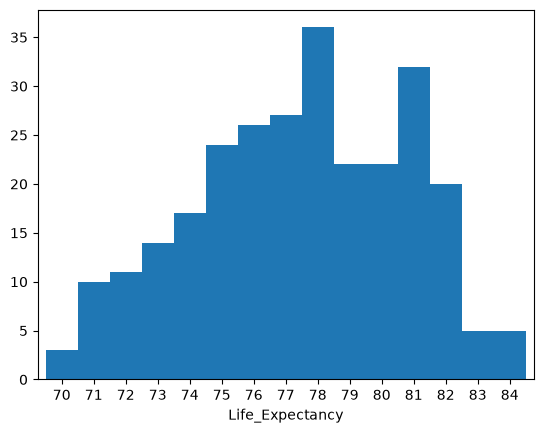

In [182]:
healthexp.Life_Expectancy.astype(int).value_counts().sort_index().plot.bar(width=1, rot=0)
plt.show()

In this example, we have created a bin for age value based on their integer value.

We might adjust this be grouping ages into groups of $5$ or $10$ years.

Or we could decide how many bins we want and use `pd.cut()` to create them, like so:

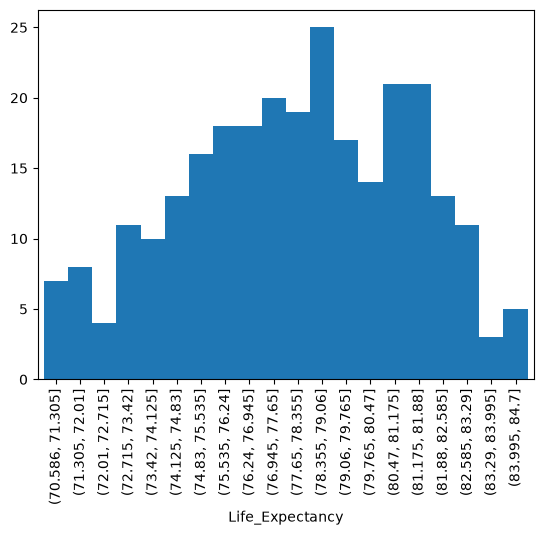

In [239]:
n_bins = 20
pd.cut(healthexp.Life_Expectancy, n_bins).value_counts().sort_index().plot.bar(width=1)
plt.show()

## Using Pandas' histogram function

So, we see how a histogram is constructed.

Panda's histogram method `.plot.hist()` does all this work for us and adds some nice formatting touches.

To use it, we give it a numeric feature and pass it the number of bins by which we want to group the observations. 

The default value is $10$.

Here we choose $20$ to mirror our bespoke version.

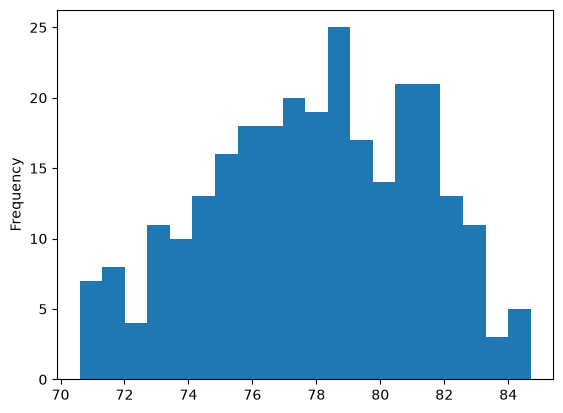

In [240]:
healthexp.Life_Expectancy.plot.hist(bins=n_bins)
plt.show()

Notice how the histogram function represents the x and y axes. 

The **x axis** is represented as a continuum, even though the bars themselves are discrete.

This allows the axis to remain true to the feature domain it represents, as well as to remain unchanged as the `bins` argument changes.

The **y axis** is now labeled "Frequency".

## Showing populations

As we might imagine, the distribution of life expectancy ages vary by country.

To visualize this, we can group the age date by nation and show each histogram separately.

We can achieve this by creating a wide table in which `Country` is projected onto the column, and `Year` the row axis (or index), and the values come from `Life_Expectancy`.

Panda's `.pivot()` lets us do this.

In [242]:
life_exp_wide = healthexp.pivot(index='Year', columns='Country', values='Life_Expectancy')
life_exp_wide.head(10)

Country,Canada,France,Germany,Great Britain,Japan,USA
Year,,,,,,
1970,NaN,72.2,70.6,71.9,72.0,70.9
1971,72.8,NaN,70.8,71.9,72.9,71.2
1972,NaN,NaN,71.0,NaN,73.2,71.2
1973,NaN,NaN,71.3,NaN,73.4,71.4
1974,NaN,NaN,71.5,NaN,73.7,72.0
1975,NaN,73.0,71.4,NaN,74.3,72.7
1976,73.8,NaN,71.8,NaN,74.8,72.9
1977,NaN,NaN,72.5,NaN,75.3,73.3
1978,NaN,NaN,72.4,NaN,75.7,73.5


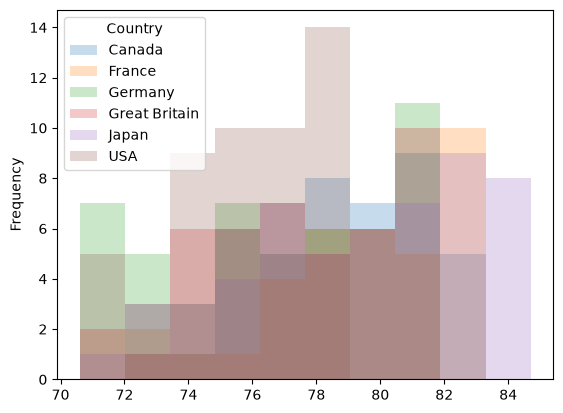

In [236]:
life_exp_wide.plot.hist(alpha=.25)
plt.show()

Here we can see that this histogram we created above masked the fact that the underlying data contained many populations.

To better visualize the differences, we can break these out using subplots as follows.

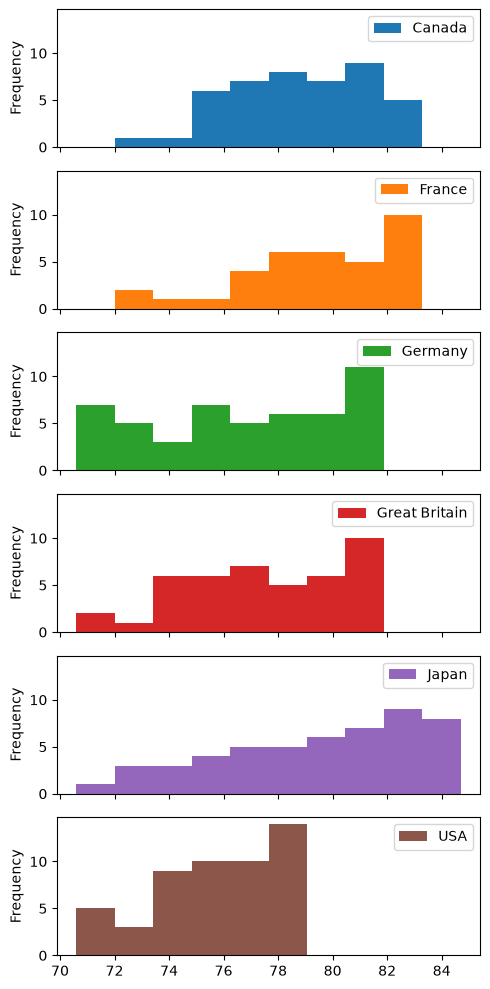

In [237]:
life_exp_wide.plot.hist(subplots=True, figsize=(5, 10), sharey=True)
plt.tight_layout()
plt.show()